In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets


In [9]:
iris = datasets.load_iris()
iris_data = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_data.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(iris_data)


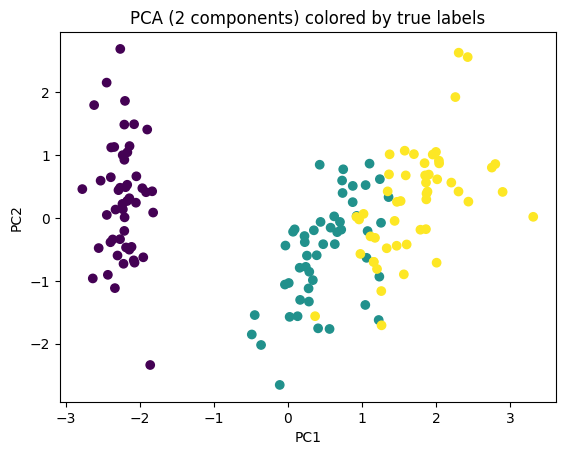

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_scaled = pca.fit_transform(X_scaled)

plt.scatter(pca_scaled[:,0], pca_scaled[:,1], c=iris.target, cmap="viridis")
plt.title("PCA (2 components) colored by true labels")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


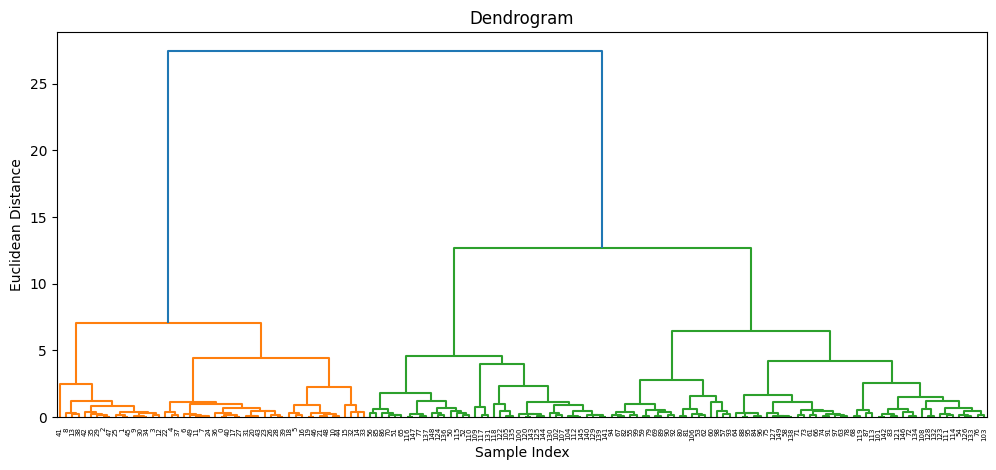

In [12]:
import scipy.cluster.hierarchy as sc

plt.figure(figsize=(12,5))
sc.dendrogram(sc.linkage(pca_scaled, method="ward"))
plt.title("Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Euclidean Distance")
plt.show()


In [13]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=2, metric="euclidean", linkage="ward")
labels = cluster.fit_predict(pca_scaled)

print("Cluster labels:", labels)


Cluster labels: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


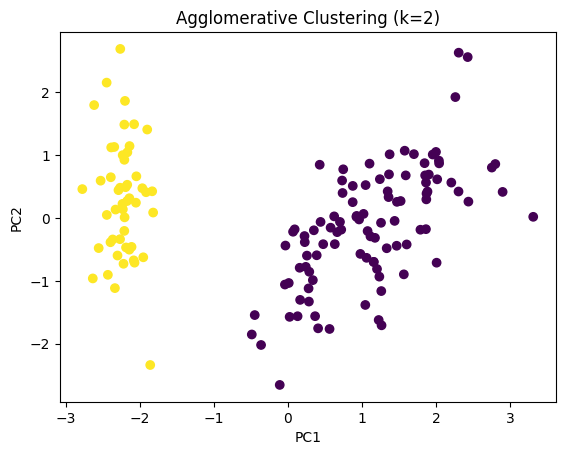

In [14]:
plt.scatter(pca_scaled[:,0], pca_scaled[:,1], c=labels, cmap="viridis")
plt.title("Agglomerative Clustering (k=2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [15]:
from sklearn.metrics import silhouette_score

silhouette_coefficients = []
k_values = range(2, 11)

for k in k_values:
    agglo = AgglomerativeClustering(n_clusters=k, metric="euclidean", linkage="ward")
    labels_k = agglo.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_k)
    silhouette_coefficients.append(score)

for k, score in zip(k_values, silhouette_coefficients):
    print(f"k={k}, silhouette={score:.4f}")


k=2, silhouette=0.5770
k=3, silhouette=0.4467
k=4, silhouette=0.4006
k=5, silhouette=0.3306
k=6, silhouette=0.3149
k=7, silhouette=0.3170
k=8, silhouette=0.3109
k=9, silhouette=0.3114
k=10, silhouette=0.3161


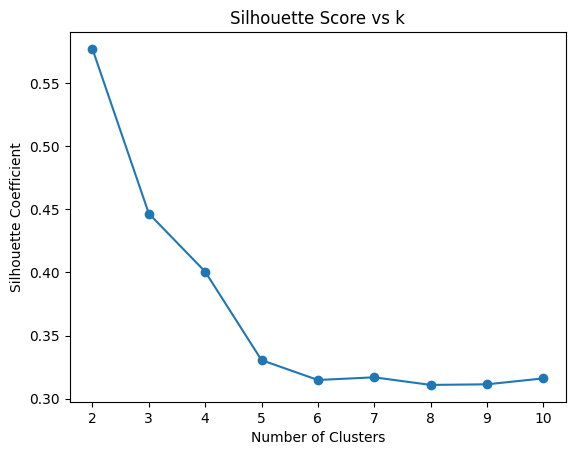

In [16]:
plt.plot(k_values, silhouette_coefficients, marker="o")
plt.xticks(k_values)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.title("Silhouette Score vs k")
plt.show()
